### Time Series Changes and Versioning with TimeDB

This notebook demonstrates how to update values, tags, and annotations and view all versions:
1. **Flat series** — in-place updates for fact data (no versioning)
2. **Overlapping series** — corrections with full audit trail (knowledge_time preserved, change_time advances)
3. **Flexible update lookups** — using `batch_id`, `knowledge_time`, or just `valid_time`
4. **Reading history** — query with `read(overlapping=True)` or the full audit log with `read(overlapping=True, include_updates=True)`

In [1]:
try:
    import google.colab
    import urllib.request
    urllib.request.urlretrieve(
        'https://raw.githubusercontent.com/rebase-energy/timedb/main/examples/colab_setup.py',
        '/tmp/colab_setup.py'
    )
    exec(open('/tmp/colab_setup.py').read())
except ImportError:
    pass  # Not running in Google Colab


In [2]:
import timedb as td
from timedb import TimeSeries, DataShape
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone, timedelta
import numpy as np

td.delete()
td.create()

Creating database schema...
✓ Schema created successfully


## Part 1: Insert Time Series (Flat and Overlapping)

First, let's insert two time series:
- **Flat series**: `meter_reading` - for fact data that can be corrected in-place
- **Overlapping series**: `temperature` - for estimates/forecasts with version history

For the overlapping series, we'll insert **TWO batches** to demonstrate versioning:
- **Batch 1**: Initial forecast (knowledge_time = 00:00)
- **Batch 2**: Revised forecast (knowledge_time = 02:00) with slightly different values

This means each valid_time will have 2 versions before we even start updating!

In [3]:
# Create time series with hourly data for 24 hours
base_time = datetime(2025, 1, 1, 0, 0, tzinfo=timezone.utc)
times = [base_time + timedelta(hours=i) for i in range(24)]
np.random.seed(42)

td.create_series(name="meter_reading", unit="dimensionless")
td.create_series(name="temperature", unit="dimensionless", overlapping=True)

ts_flat = TimeSeries.from_pandas(
    pd.DataFrame({'valid_time': times, 'value': [round(100 + i*5 + np.random.normal(0, 0.2), 2) for i in range(24)]}),
    unit="dimensionless",
)
result_flat = td.get_series("meter_reading").insert(ts_flat)

ts_batch_1 = TimeSeries.from_pandas(
    pd.DataFrame({'valid_time': times, 'value': [round(20 + 5*np.sin(2*np.pi*i/24) + np.random.normal(0, 0.5), 2) for i in range(24)]}),
    unit="dimensionless",
)
result_batch_1 = td.get_series("temperature").insert(ts_batch_1, knowledge_time=base_time)

ts_batch_2 = TimeSeries.from_pandas(
    pd.DataFrame({'valid_time': times, 'value': [round(20 + 5*np.sin(2*np.pi*i/24) + np.random.normal(0, 1), 2) for i in range(24)]}),
    unit="dimensionless",
)
result_batch_2 = td.get_series("temperature").insert(ts_batch_2, knowledge_time=base_time + timedelta(hours=2))

batch_id_1, batch_id_2 = result_batch_1.batch_id, result_batch_2.batch_id
knowledge_time_1, knowledge_time_2 = base_time, base_time + timedelta(hours=2)
series_id_temp, series_id_meter = result_batch_1.series_id, result_flat.series_id

print(f"Inserted meter_reading (flat) and temperature (overlapping) with 2 versions")

Inserted meter_reading (flat) and temperature (overlapping) with 2 versions


## Part 2: Read and Plot the Time Series

Let's read back both time series and visualize them.

For the overlapping series, `read()` returns the **latest value** (highest `knowledge_time`, latest `change_time`).
Use `read(overlapping=True)` to see all forecast runs, or `read(overlapping=True, include_updates=True)` for the full correction chain.

In [4]:
# Read both time series — read() returns a TimeSeries; call .to_pandas() for a DataFrame
# For overlapping, read() returns the LATEST version (highest knowledge_time, latest change_time)
ts_temp_read = td.get_series("temperature").read(
    start_valid=base_time,
    end_valid=base_time + timedelta(hours=24),
)
display(ts_temp_read)
df_temp_read = ts_temp_read.to_pandas()

ts_meter_read = td.get_series("meter_reading").read(
    start_valid=base_time,
    end_valid=base_time + timedelta(hours=24),
)
df_meter_read = ts_meter_read.to_pandas()
display(ts_meter_read)

# Also read forecast history to see both batches
ts_temp_history = td.get_series("temperature").read(
    start_valid=base_time,
    end_valid=base_time + timedelta(hours=24),
    overlapping=True,  # one row per (knowledge_time, valid_time)
)
display(ts_temp_history)
df_temp_history = ts_temp_history.to_pandas()


Name,temperature
Shape,SIMPLE
Rows,24
Timezone,UTC
Timeseries type,OVERLAPPING
valid_time,temperature
2025-01-01 00:00,20.34
2025-01-01 01:00,19.53
2025-01-01 02:00,22.82
…,…
2025-01-01 21:00,15.82


Name,meter_reading
Shape,SIMPLE
Rows,24
Timezone,UTC
valid_time,meter_reading
2025-01-01 00:00,100.1
2025-01-01 01:00,104.97
2025-01-01 02:00,110.13
…,…
2025-01-01 21:00,204.95
2025-01-01 22:00,210.01


TimeSeries
┌───────────────────────────────────────────────────┐
│  Name:             temperature                    │
│  Shape:            VERSIONED                      │
│  Rows:             48                             │
│  Timezone:         UTC                            │
│  Timeseries type:  OVERLAPPING                    │
├───────────────────────────────────────────────────┤
│                                      temperature  │
│  2025-01-01 00:00, 2025-01-01 00:00        19.73  │
│  2025-01-01 00:00, 2025-01-01 01:00        21.35  │
│  2025-01-01 00:00, 2025-01-01 02:00        21.92  │
│  ...                                         ...  │
│  2025-01-01 02:00, 2025-01-01 21:00        15.82  │
│  2025-01-01 02:00, 2025-01-01 22:00        17.86  │
│  2025-01-01 02:00, 2025-01-01 23:00        20.24  │
└───────────────────────────────────────────────────┘

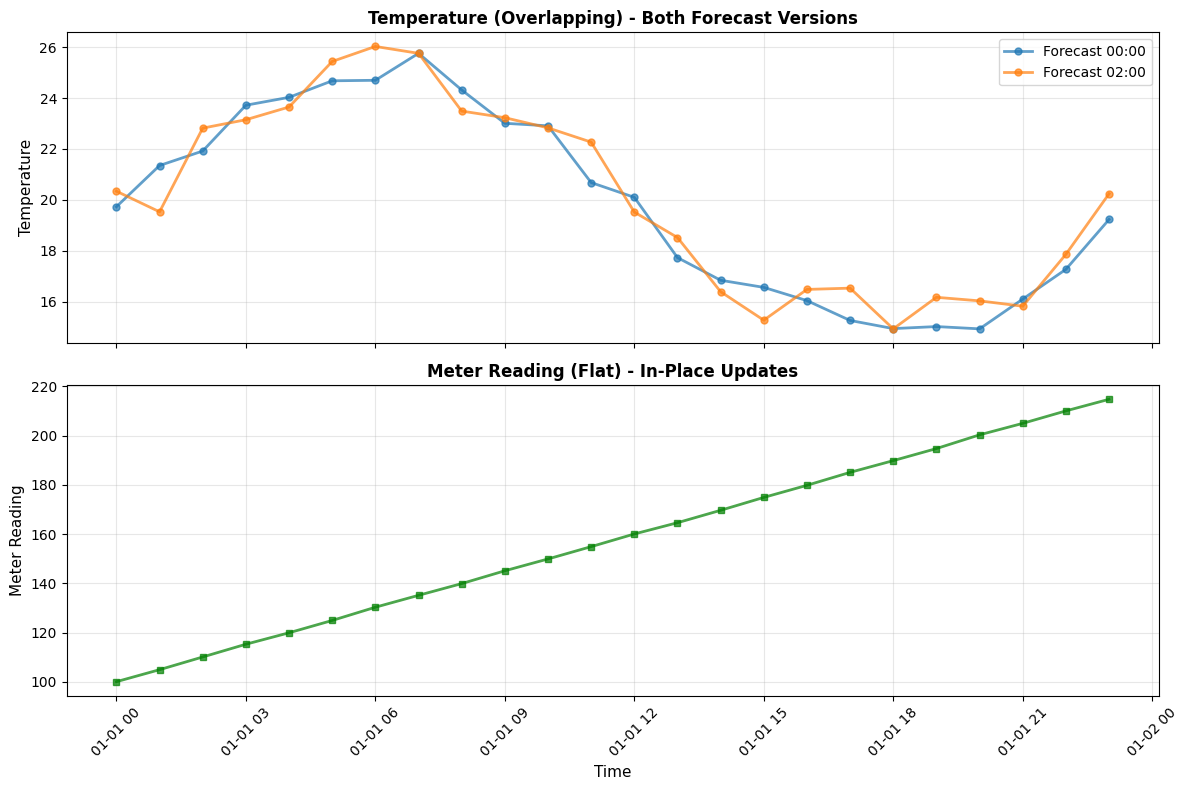

✓ Both time series plotted successfully!


In [5]:
# Plot both time series
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Temperature (overlapping series) - show BOTH forecasts
ax1 = axes[0]

# Get both versions from df_temp_history
for knowledge_time in df_temp_history.index.get_level_values('knowledge_time').unique():
    df_version = df_temp_history.xs(knowledge_time, level='knowledge_time')
    temp_y = df_version['value'].astype(float)
    label = f"Forecast {knowledge_time.strftime('%H:%M')}"
    ax1.plot(df_version.index.get_level_values('valid_time'), temp_y, 
             marker='o', linewidth=2, markersize=5, alpha=0.7, label=label)

ax1.set_ylabel('Temperature', fontsize=11)
ax1.set_title('Temperature (Overlapping) - Both Forecast Versions', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Meter reading (flat series)
ax2 = axes[1]
meter_y = df_meter_read['value'].astype(float)
ax2.plot(df_meter_read.index, meter_y, marker='s', linewidth=2, markersize=5, 
         color='green', alpha=0.7)
ax2.set_ylabel('Meter Reading', fontsize=11)
ax2.set_xlabel('Time', fontsize=11)
ax2.set_title('Meter Reading (Flat) - In-Place Updates', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✓ Both time series plotted successfully!")

## Part 3: Update a Flat Series (In-Place)

Flat series use **in-place updates** - there's no version history. The value is simply replaced.

This is ideal for correcting fact data like meter readings where you want to fix errors without maintaining a version trail.

In [6]:
# Update a flat series - simple, no batch_id needed!
update_time_flat = base_time + timedelta(hours=5)

# Read current value
original_meter_value = float(df_meter_read.loc[update_time_flat, "value"])
print(f"Original meter reading at {update_time_flat}: {original_meter_value:.2f}")

# Update the flat series - just need series_id and valid_time!
corrected_meter_value = 130.0

result = td.get_series("meter_reading").update_records(updates=[{
    "valid_time": update_time_flat,
    "value": corrected_meter_value,
    "annotation": "Corrected: faulty meter reading",
    "changed_by": "technician@example.com",
}])

print(f"\nFlat update completed!")
print(f"  Updated: {original_meter_value:.2f} -> {corrected_meter_value:.2f}")
print(f"  Updated records: {len(result)}")

# Verify the update - read it back
df_meter_after = td.get_series("meter_reading").read(
    start_valid=update_time_flat,
    end_valid=update_time_flat + timedelta(hours=1),
).to_pandas()
print(f"\nVerification - current value: {float(df_meter_after.iloc[0]['value']):.2f}")

Original meter reading at 2025-01-01 05:00:00+00:00: 124.95

Flat update completed!
  Updated: 124.95 -> 130.00
  Updated records: 1

Verification - current value: 130.00


## Part 4: Update Overlapping Series (Versioned)

Overlapping series create **new versions** on each update - the old value is preserved with its original `knowledge_time`.

Since we now have **two batches** (two versions per valid_time), we can demonstrate three ways to identify which version to update:

1. **Using `batch_id`**: Target the latest version within a specific batch
2. **Using `knowledge_time`**: Target an exact version by its knowledge_time  
3. **Using just `valid_time`**: Target the latest version overall (most convenient!)

In [7]:
# We'll update three different time points using each method
update_time_1 = base_time + timedelta(hours=6)   # Method 1: batch_id
update_time_2 = base_time + timedelta(hours=12)  # Method 2: knowledge_time
update_time_3 = base_time + timedelta(hours=18)  # Method 3: just valid_time

# Show current values before updates
print("Current values BEFORE corrections:\n")
for ut in [update_time_1, update_time_2, update_time_3]:
    versions = df_temp_history.xs(ut, level='valid_time')
    print(f"  {ut}:")
    for knowledge_time, row in versions.iterrows():
        kt = knowledge_time if not isinstance(knowledge_time, tuple) else knowledge_time[0]
        print(f"    knowledge_time={kt}: {float(row['value']):.2f}")

# METHOD 1: Update using batch_id (targeting Batch 1)
print(f"\nMETHOD 1: batch_id — correct {update_time_1} in Batch 1")
result_1 = td.get_series("temperature").update_records(updates=[{
    "batch_id": batch_id_1,
    "valid_time": update_time_1,
    "value": 29.0,
    "annotation": "Corrected via batch_id (targeting Batch 1)",
    "tags": ["method_batch_id"],
    "changed_by": "demo@example.com",
}])
print(f"  Updated {len(result_1)} record (correction preserves knowledge_time, advances change_time)")

# METHOD 2: Update using knowledge_time (exact version lookup)
print(f"\nMETHOD 2: knowledge_time — correct {update_time_2} from Batch 1 (knowledge_time={knowledge_time_1})")
result_2 = td.get_series("temperature").update_records(updates=[{
    "knowledge_time": knowledge_time_1,
    "valid_time": update_time_2,
    "value": 27.0,
    "annotation": "Corrected via knowledge_time (exact version from Batch 1)",
    "tags": ["method_knowledge_time"],
    "changed_by": "demo@example.com",
}])
print(f"  Updated {len(result_2)} record")

# METHOD 3: Update using just valid_time (latest version)
print(f"\nMETHOD 3: valid_time only — correct latest version at {update_time_3}")
result_3 = td.get_series("temperature").update_records(updates=[{
    "valid_time": update_time_3,
    "value": 25.0,
    "annotation": "Corrected via latest lookup (most convenient!)",
    "tags": ["method_latest"],
    "changed_by": "demo@example.com",
}])
print(f"  Updated {len(result_3)} record")

Current values BEFORE corrections:

  2025-01-01 06:00:00+00:00:
    knowledge_time=2025-01-01 00:00:00+00:00: 24.70
    knowledge_time=2025-01-01 02:00:00+00:00: 26.03
  2025-01-01 12:00:00+00:00:
    knowledge_time=2025-01-01 00:00:00+00:00: 20.10
    knowledge_time=2025-01-01 02:00:00+00:00: 19.52
  2025-01-01 18:00:00+00:00:
    knowledge_time=2025-01-01 00:00:00+00:00: 14.94
    knowledge_time=2025-01-01 02:00:00+00:00: 14.93

METHOD 1: batch_id — correct 2025-01-01 06:00:00+00:00 in Batch 1
  Updated 1 record (correction preserves knowledge_time, advances change_time)

METHOD 2: knowledge_time — correct 2025-01-01 12:00:00+00:00 from Batch 1 (knowledge_time=2025-01-01 00:00:00+00:00)
  Updated 1 record

METHOD 3: valid_time only — correct latest version at 2025-01-01 18:00:00+00:00
  Updated 1 record


## Part 5: View Forecast History After Corrections

Now let's read the overlapping series with `overlapping=True` to see the current best value
for each forecast run × valid_time combination. Corrections are reflected here — the corrected
values appear under their original `knowledge_time`.

To see every row ever written (including the pre-correction originals), use `overlapping=True, include_updates=True`
which returns a `(knowledge_time, change_time, valid_time)` multi-index.

In [8]:
# Read history for the time points we corrected
df_versions = td.get_series("temperature").read(
    start_valid=base_time + timedelta(hours=5),
    end_valid=base_time + timedelta(hours=20),
    overlapping=True,  # one row per (knowledge_time, valid_time), latest correction
).to_pandas()

print("Values AFTER corrections (latest per forecast run × valid_time):\n")
for ut, method in [(update_time_1, "batch_id"), (update_time_2, "knowledge_time"), (update_time_3, "valid_time")]:
    print(f"Valid time: {ut} (corrected via {method})")
    try:
        versions = df_versions.xs(ut, level="valid_time")
        for kt, row in versions.iterrows():
            knowledge_time = kt if not isinstance(kt, tuple) else kt[0]
            value = float(row["value"])
            if knowledge_time == knowledge_time_1:
                source = "Batch 1"
            elif knowledge_time == knowledge_time_2:
                source = "Batch 2"
            else:
                source = "Other"
            print(f"  knowledge_time={knowledge_time}: {value:.2f}  [{source}]")
    except KeyError:
        print(f"  No data for this time point")
    print()

print("Corrections preserve the original knowledge_time and advance change_time.")
print("Use read(overlapping=True, include_updates=True) to see the full correction chain including original values.")

Values AFTER corrections (latest per forecast run × valid_time):

Valid time: 2025-01-01 06:00:00+00:00 (corrected via batch_id)
  knowledge_time=2025-01-01 00:00:00+00:00: 29.00  [Batch 1]
  knowledge_time=2025-01-01 02:00:00+00:00: 26.03  [Batch 2]

Valid time: 2025-01-01 12:00:00+00:00 (corrected via knowledge_time)
  knowledge_time=2025-01-01 00:00:00+00:00: 27.00  [Batch 1]
  knowledge_time=2025-01-01 02:00:00+00:00: 19.52  [Batch 2]

Valid time: 2025-01-01 18:00:00+00:00 (corrected via valid_time)
  knowledge_time=2025-01-01 00:00:00+00:00: 14.94  [Batch 1]
  knowledge_time=2025-01-01 02:00:00+00:00: 25.00  [Batch 2]

Corrections preserve the original knowledge_time and advance change_time.
Use read(overlapping=True, include_updates=True) to see the full correction chain including original values.


## Part 6: Full Audit Log (overlapping=True, include_updates=True)

`read(overlapping=True, include_updates=True)` returns **every row ever written**, including the pre-correction originals.
The index has three levels: `(knowledge_time, change_time, valid_time)`.

This is the complete, immutable record of all writes — useful for compliance audits or
debugging a correction chain.

In [9]:
# Read the full audit log: every row ever written for the corrected hours
df_audit = td.get_series("temperature").read(
    start_valid=base_time + timedelta(hours=5),
    end_valid=base_time + timedelta(hours=20),
    overlapping=True, include_updates=True,  # all rows, index: (knowledge_time, change_time, valid_time)
).to_pandas()

print(f"Audit log index levels: {df_audit.index.names}")
print(f"Columns: {list(df_audit.columns)}")
print(f"Total rows: {len(df_audit)}  (original inserts + correction rows)\n")

# Show the correction chain for one valid_time
for ut, method in [(update_time_1, "batch_id"), (update_time_2, "knowledge_time"), (update_time_3, "valid_time")]:
    print(f"Valid time: {ut}  (corrected via {method})")
    try:
        chain = df_audit.xs(ut, level="valid_time")
        for (kt, ct), row in chain.iterrows():
            value = float(row["value"])
            changed_by = row.get("changed_by") or "-"
            annotation = row.get("annotation") or "-"
            if kt == knowledge_time_1:
                batch = "Batch 1"
            elif kt == knowledge_time_2:
                batch = "Batch 2"
            else:
                batch = "Other"
            print(f"  kt={kt.strftime('%H:%M')}  ct={ct.strftime('%H:%M:%S')}  "
                  f"value={value:.2f}  changed_by={changed_by}  annotation={annotation}  [{batch}]")
    except KeyError:
        print("  (no data)")
    print()

print("Each correction added a new row with the same knowledge_time but a later change_time.")

Audit log index levels: ['knowledge_time', 'change_time', 'valid_time']
Columns: ['value', 'changed_by', 'annotation']
Total rows: 33  (original inserts + correction rows)

Valid time: 2025-01-01 06:00:00+00:00  (corrected via batch_id)
  kt=00:00  ct=14:40:02  value=24.70  changed_by=nan  annotation=nan  [Batch 1]
  kt=00:00  ct=14:40:03  value=29.00  changed_by=demo@example.com  annotation=Corrected via batch_id (targeting Batch 1)  [Batch 1]
  kt=02:00  ct=14:40:02  value=26.03  changed_by=nan  annotation=nan  [Batch 2]

Valid time: 2025-01-01 12:00:00+00:00  (corrected via knowledge_time)
  kt=00:00  ct=14:40:02  value=20.10  changed_by=nan  annotation=nan  [Batch 1]
  kt=00:00  ct=14:40:03  value=27.00  changed_by=demo@example.com  annotation=Corrected via knowledge_time (exact version from Batch 1)  [Batch 1]
  kt=02:00  ct=14:40:02  value=19.52  changed_by=nan  annotation=nan  [Batch 2]

Valid time: 2025-01-01 18:00:00+00:00  (corrected via valid_time)
  kt=00:00  ct=14:40:02  v

## Part 7: Visualize Original vs Updated

Let's plot both versions to see the changes visually.

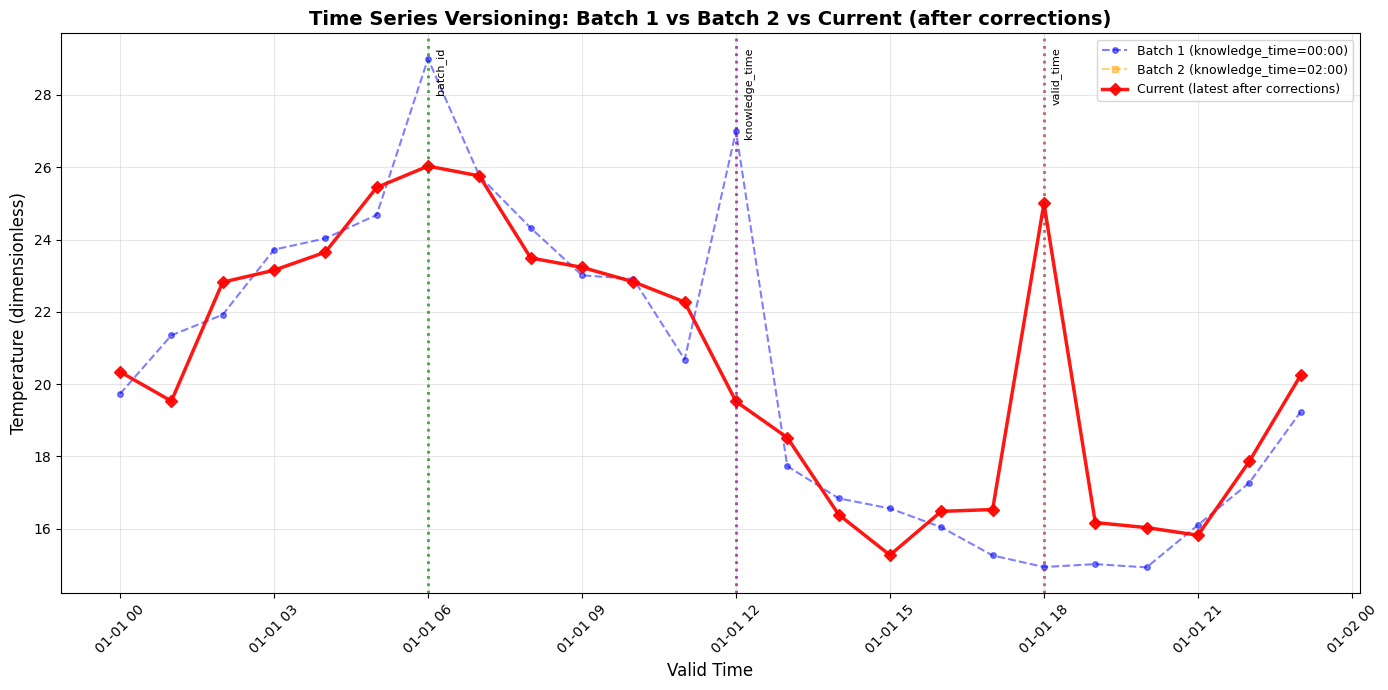

Dotted lines mark the three corrected time points (hours 6, 12, 18)


In [10]:
# Read current (latest) version after all corrections
df_current = td.get_series("temperature").read(
    start_valid=base_time,
    end_valid=base_time + timedelta(hours=24),
).to_pandas()

# Also read history to compare Batch 1 and Batch 2 values
df_history_full = td.get_series("temperature").read(
    start_valid=base_time,
    end_valid=base_time + timedelta(hours=24),
    overlapping=True,  # latest correction per (knowledge_time, valid_time)
).to_pandas()

# Plot comparison
plt.figure(figsize=(14, 7))

# Extract values from each batch
batch1_values = []
batch2_values = []
for vt in times:
    try:
        versions = df_history_full.xs(vt, level="valid_time")
        for kt, row in versions.iterrows():
            knowledge_time = kt if not isinstance(kt, tuple) else kt[0]
            if knowledge_time == knowledge_time_1:
                batch1_values.append(float(row["value"]))
            elif knowledge_time == knowledge_time_2:
                batch2_values.append(float(row["value"]))
    except KeyError:
        pass

# Plot Batch 1 (original or corrected)
plt.plot(times, batch1_values,
         marker="o", linewidth=1.5, markersize=4,
         label=f'Batch 1 (knowledge_time={knowledge_time_1.strftime("%H:%M")})',
         color="blue", alpha=0.5, linestyle="--")

# Plot Batch 2 (original or corrected)
plt.plot(times, batch2_values,
         marker="s", linewidth=1.5, markersize=4,
         label=f'Batch 2 (knowledge_time={knowledge_time_2.strftime("%H:%M")})',
         color="orange", alpha=0.5, linestyle="--")

# Plot current (latest after corrections)
current_y = df_current["value"].astype(float)
plt.plot(df_current.index, current_y,
         marker="D", linewidth=2.5, markersize=6,
         label="Current (latest after corrections)", color="red", alpha=0.9)

# Highlight the corrected points
for ut, label, color in [
    (update_time_1, "batch_id", "green"),
    (update_time_2, "knowledge_time", "purple"),
    (update_time_3, "valid_time", "brown"),
]:
    plt.axvline(x=ut, color=color, linestyle=":", linewidth=2, alpha=0.7)
    plt.annotate(label, xy=(ut, plt.ylim()[1]), xytext=(5, -10),
                 textcoords="offset points", fontsize=8, rotation=90, va="top")

plt.xlabel("Valid Time", fontsize=12)
plt.ylabel("Temperature (dimensionless)", fontsize=12)
plt.title("Time Series Versioning: Batch 1 vs Batch 2 vs Current (after corrections)",
          fontsize=14, fontweight="bold")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Dotted lines mark the three corrected time points (hours 6, 12, 18)")

### Summary

- **Flat series**: in-place updates via `td.get_series("name").update_records(updates=[{"valid_time": dt, "value": ...}])`
- **Overlapping series**: corrections insert a new row that **preserves `knowledge_time`** and stamps `change_time = now()`, keeping the forecast run identity intact
- **Three lookup methods** for overlapping: `batch_id`, `knowledge_time`, or just `valid_time` (targets latest)
- **Read flags**:
  - `read()` — latest value per `valid_time` (default)
  - `read(overlapping=True)` — latest correction per `(knowledge_time, valid_time)`, index `[knowledge_time, valid_time]`
  - `read(overlapping=True, include_updates=True)` — full correction chain, index `[knowledge_time, change_time, valid_time]`
- **Updateable fields**: `value`, `annotation`, `tags`, `changed_by`